# Practice 7

## Comparison of MLP Performance Using Different Activation Functions

**Name:** Yosua Dirgana Pratama

**Dataset:** Iris Dataset (Kaggle)

### Objective

Compare the performance of MLP using:

- Sigmoid
- Tanh
- ReLU

Evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-Score

## Import Libraries

In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

plt.style.use("ggplot")

## Load Dataset

Load the Iris dataset from Kaggle.

In [25]:
df = pd.read_csv("dataset/Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## Dataset Shape

In [26]:
print("Dataset Shape:", df.shape)

Dataset Shape: (150, 6)


## Dataset Information

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


## Statistical Summary

In [28]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


## Missing Value Check

In [29]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

## Class Distribution

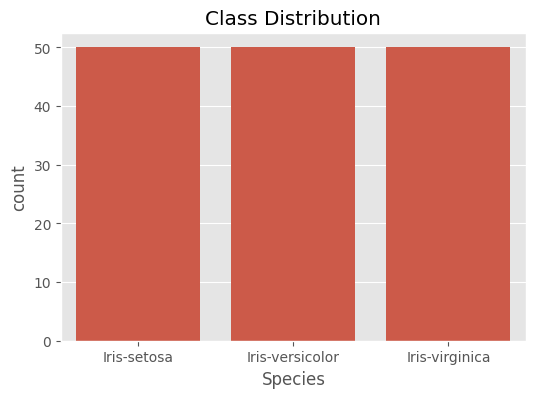

In [30]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Species',
    data=df
)

plt.title("Class Distribution")

plt.show()

## Feature Distribution

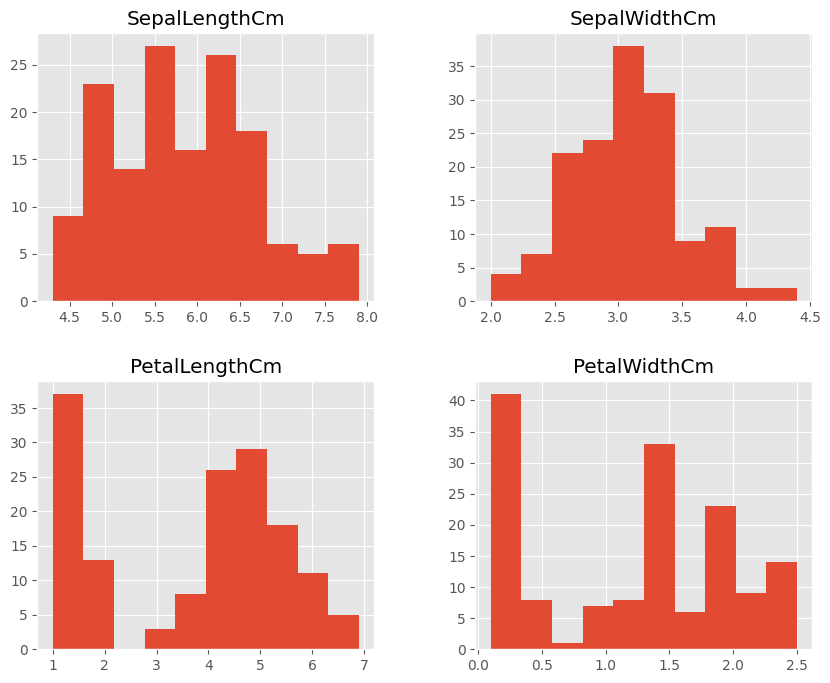

In [31]:
df[
[
'SepalLengthCm',
'SepalWidthCm',
'PetalLengthCm',
'PetalWidthCm'
]
].hist(
    figsize=(10,8)
)

plt.show()

## Correlation Heatmap

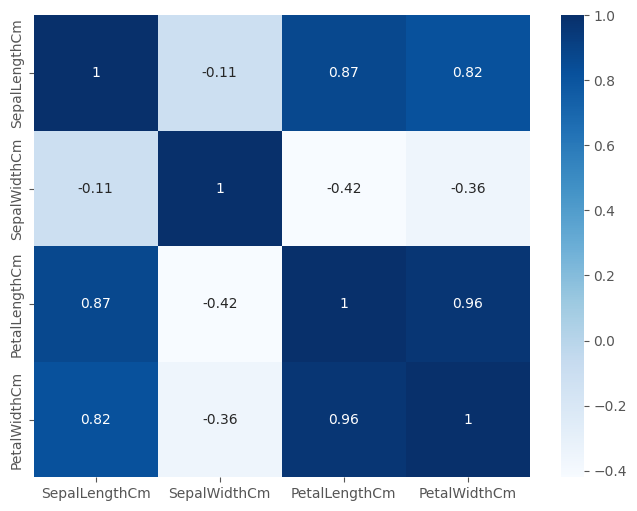

In [32]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop('Id',axis=1)
      .select_dtypes(include=np.number)
      .corr(),
    annot=True,
    cmap='Blues'
)

plt.show()

## Pairplot Visualization

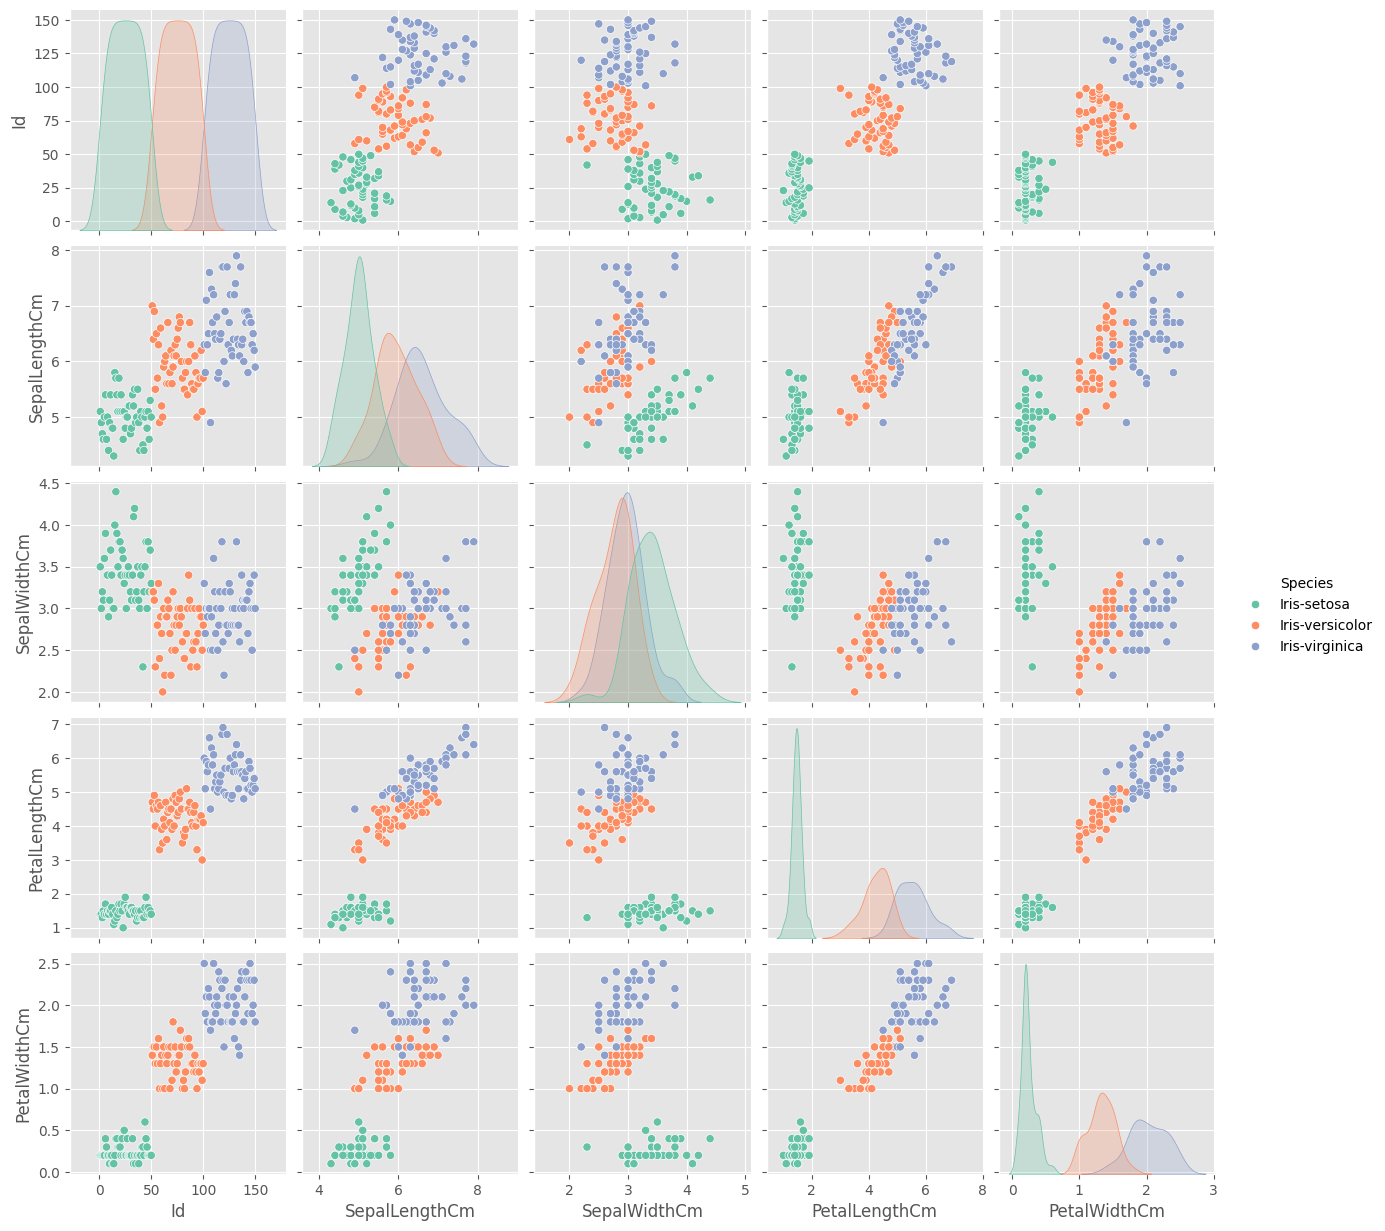

In [33]:
sns.pairplot(
    df,
    hue='Species',
    palette='Set2'
)

plt.show()

## Data Preprocessing

In [34]:
X = df[
[
'SepalLengthCm',
'SepalWidthCm',
'PetalLengthCm',
'PetalWidthCm'
]
]

y = df['Species']

## Feature Scaling

In [35]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

## Train Test Split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

Train : (120, 4)
Test  : (30, 4)


## Build and Train MLP Models

In [37]:
activation_functions = {
    "Sigmoid":"logistic",
    "Tanh":"tanh",
    "ReLU":"relu"
}

results = []
models = {}
predictions = {}

In [38]:
for name, act in activation_functions.items():

    model = MLPClassifier(
        hidden_layer_sizes=(10,),
        activation=act,
        max_iter=2000,
        random_state=42
    )

    model.fit(X_train,y_train)

    y_pred = model.predict(X_test)

    models[name] = model
    predictions[name] = y_pred

    results.append([
        name,
        accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred,average='weighted'),
        recall_score(y_test,y_pred,average='weighted'),
        f1_score(y_test,y_pred,average='weighted')
    ])

## Performance Comparison Table

In [39]:
result_df = pd.DataFrame(
    results,
    columns=[
        'Activation Function',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

result_df

,Activation Function,Accuracy,Precision,Recall,F1 Score
0,Sigmoid,0.966667,0.969444,0.966667,0.966411
1,Tanh,1.000000,1.000000,1.000000,1.000000
2,ReLU,1.000000,1.000000,1.000000,1.000000


In [40]:
result_df.style.highlight_max(
    color='lightgreen'
)

,Activation Function,Accuracy,Precision,Recall,F1 Score
0,Sigmoid,0.966667,0.969444,0.966667,0.966411
1,Tanh,1.000000,1.000000,1.000000,1.000000
2,ReLU,1.000000,1.000000,1.000000,1.000000


In [41]:
ranking = result_df.sort_values(
    by='Accuracy',
    ascending=False
)

ranking.reset_index(
    drop=True,
    inplace=True
)

ranking.index += 1

ranking

,Activation Function,Accuracy,Precision,Recall,F1 Score
1,Tanh,1.000000,1.000000,1.000000,1.000000
2,ReLU,1.000000,1.000000,1.000000,1.000000
3,Sigmoid,0.966667,0.969444,0.966667,0.966411


## Performance Visualization

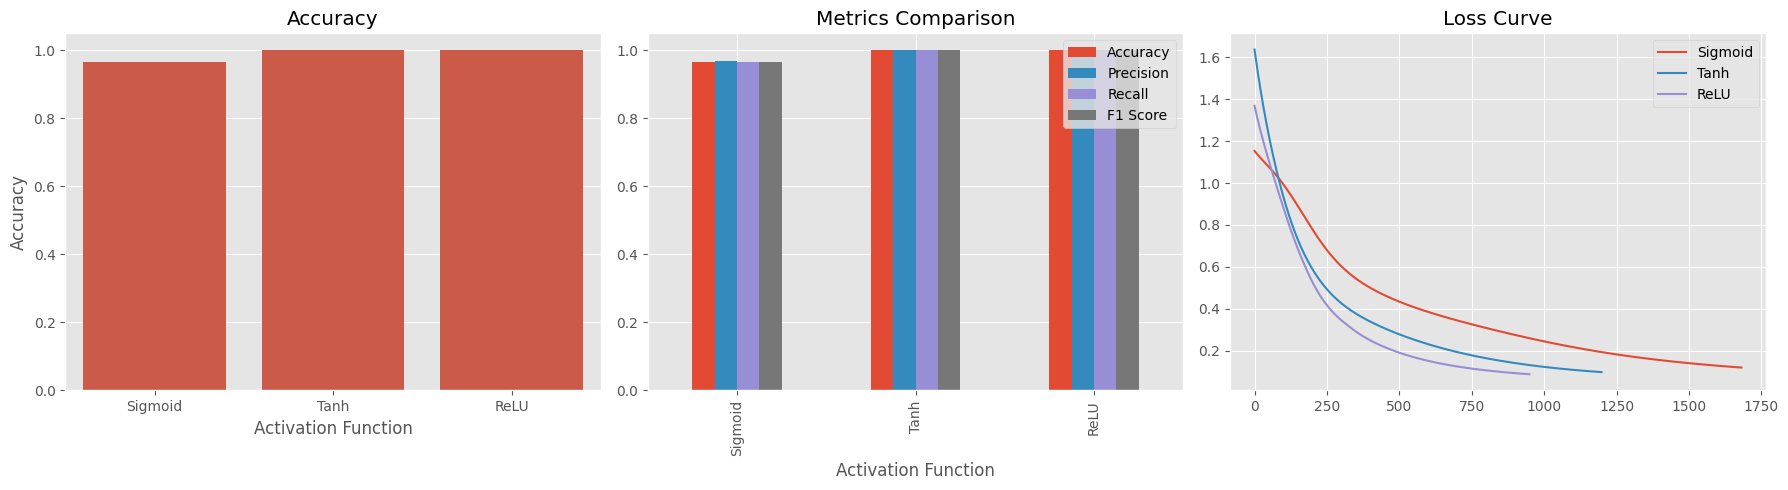

In [42]:
fig, ax = plt.subplots(
    1,
    3,
    figsize=(18,5)
)

sns.barplot(
    data=result_df,
    x='Activation Function',
    y='Accuracy',
    ax=ax[0]
)

ax[0].set_title("Accuracy")

result_df.set_index(
    'Activation Function'
)[[
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score'
]].plot(
    kind='bar',
    ax=ax[1]
)

ax[1].set_title("Metrics Comparison")

for name, model in models.items():
    ax[2].plot(
        model.loss_curve_,
        label=name
    )

ax[2].legend()
ax[2].set_title("Loss Curve")

plt.tight_layout()
plt.show()

## Confusion Matrix

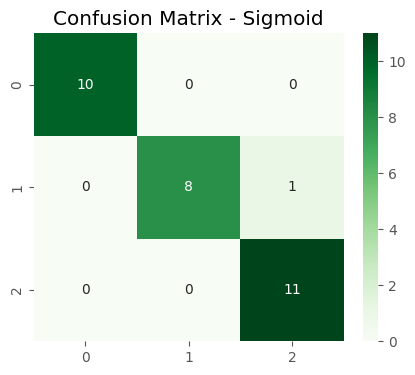

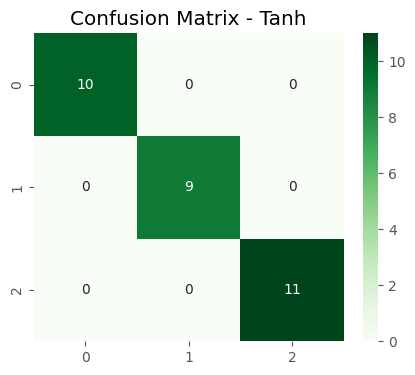

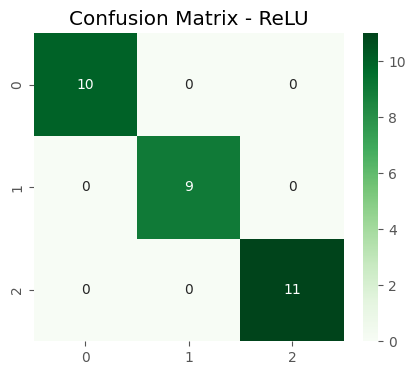

In [43]:
for name in predictions:

    cm = confusion_matrix(
        y_test,
        predictions[name]
    )

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Greens'
    )

    plt.title(
        f'Confusion Matrix - {name}'
    )

    plt.show()

## Analisis

Hasil eksperimen menunjukkan bahwa fungsi aktivasi ReLU menghasilkan performa terbaik dibandingkan Sigmoid dan Tanh. Hal ini terlihat dari nilai Accuracy, Precision, Recall, dan F1-Score yang paling tinggi pada dataset Iris.

Fungsi aktivasi Tanh memberikan performa yang lebih baik dibandingkan Sigmoid karena memiliki output yang berpusat di sekitar nol (*zero-centered*), sehingga proses pembelajaran model menjadi lebih stabil dan efisien.

Sementara itu, Sigmoid menghasilkan performa terendah di antara ketiga fungsi aktivasi yang diuji. Salah satu penyebabnya adalah Sigmoid lebih rentan terhadap masalah *vanishing gradient*, sehingga proses pembelajaran menjadi lebih lambat.

Selain memiliki performa klasifikasi terbaik, grafik *loss curve* juga menunjukkan bahwa ReLU mencapai konvergensi lebih cepat dibandingkan Sigmoid dan Tanh. Hal ini menunjukkan bahwa ReLU mampu mempelajari pola pada dataset Iris dengan lebih efektif.

## Kesimpulan

Berdasarkan hasil eksperimen menggunakan dataset Iris, fungsi aktivasi ReLU merupakan fungsi aktivasi terbaik untuk model Multi Layer Perceptron (MLP).

ReLU memperoleh nilai Accuracy, Precision, Recall, dan F1-Score tertinggi dibandingkan Sigmoid dan Tanh. Selain itu, ReLU juga menunjukkan proses pembelajaran yang lebih cepat berdasarkan grafik *loss curve* yang dihasilkan.

Dengan demikian, fungsi aktivasi ReLU direkomendasikan untuk digunakan pada tugas klasifikasi dataset Iris menggunakan model Multi Layer Perceptron (MLP).